<center><h1>Lan_Yangrong_HW2</h1></center>

Name: yangrong lan  
Github Username: CallistoAma 
USC ID: 5561147067

This notebook uses Sheet1 of the Combined Cycle Power Plant data set. A fixed random seed is used so that the train/test results are reproducible.


## 1. Combined Cycle Power Plant Data Set

The predictors are ambient temperature (AT), exhaust vacuum (V), ambient pressure (AP), and relative humidity (RH). The response is net hourly electrical energy output (PE).


### (a) Download Data

The supplied Folds5x2_pp.xlsx file is used. Per the assignment, only Sheet1 is loaded.


#### Package imports


In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


#### Get the Combined Cycle Power Plant data


In [2]:
candidate_paths = [
    Path("Folds5x2_pp.xlsx"),
    Path.cwd() / "Folds5x2_pp.xlsx",
]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Place Folds5x2_pp.xlsx in the same directory as this notebook."
    )

df = pd.read_excel(data_path, sheet_name="Sheet1")
df.columns = [str(c).strip() for c in df.columns]
expected_columns = ["AT", "V", "AP", "RH", "PE"]
assert df.columns.tolist() == expected_columns, df.columns.tolist()
assert not df.isna().any().any(), "Unexpected missing values were found."

print(f"Data source: {data_path.name} (Sheet1)")
print(f"Shape: {df.shape}")
display(df.head())


Data source: Folds5x2_pp.xlsx (Sheet1)
Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. Rows and columns

Each row is one hourly observation collected while the plant operated at full load. There are 9,568 observations and five numeric variables. AT, V, AP, and RH are predictors; PE is the response.


In [3]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
display(pd.DataFrame({
    "Role": ["Predictor", "Predictor", "Predictor", "Predictor", "Response"],
    "Meaning": [
        "Ambient temperature",
        "Exhaust vacuum",
        "Ambient pressure",
        "Relative humidity",
        "Net hourly electrical energy output",
    ],
}, index=df.columns))


Number of rows: 9,568
Number of columns: 5


,Role,Meaning
AT,Predictor,Ambient temperature
V,Predictor,Exhaust vacuum
AP,Predictor,Ambient pressure
RH,Predictor,Relative humidity
PE,Response,Net hourly electrical energy output


#### ii. Pairwise scatterplots

The plots show strong negative relationships between PE and both AT and V. AP has a weaker positive association with PE, while RH has a weaker negative association. Several predictor pairs are also related, especially AT and V, so their univariate effects may change in a multiple regression.


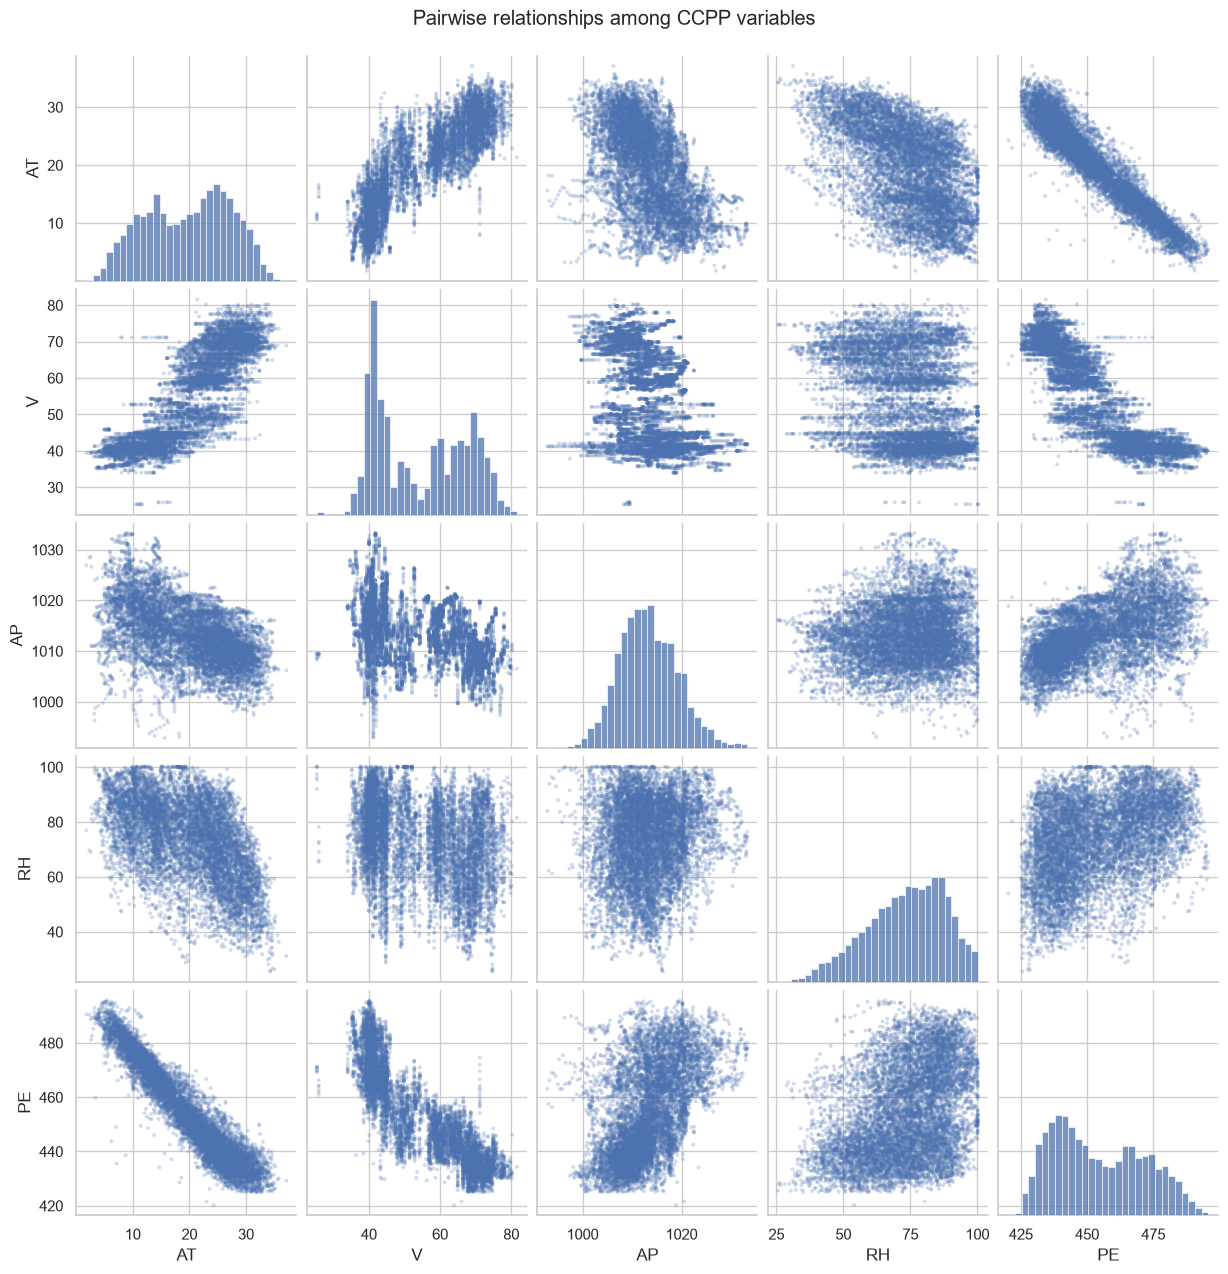

In [4]:
pair_grid = sns.pairplot(
    df,
    diag_kind="hist",
    plot_kws={"s": 8, "alpha": 0.25, "edgecolor": "none"},
    diag_kws={"bins": 30},
)
pair_grid.fig.suptitle("Pairwise relationships among CCPP variables", y=1.02)
plt.show()


#### iii. Descriptive statistics


In [5]:
summary = pd.DataFrame(index=df.columns)
summary["Mean"] = df.mean()
summary["Median"] = df.median()
summary["Minimum"] = df.min()
summary["Maximum"] = df.max()
summary["Range"] = df.max() - df.min()
summary["Q1"] = df.quantile(0.25)
summary["Q3"] = df.quantile(0.75)
summary["IQR"] = summary["Q3"] - summary["Q1"]
display(summary.round(3))


,Mean,Median,Minimum,Maximum,Range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


### (c) Simple Linear Regression

Four separate OLS models are fitted, one per predictor. Statistical significance is assessed at alpha = 0.05. Potential outliers are flagged using absolute externally studentized residuals greater than 3. The plots include the fitted regression line.


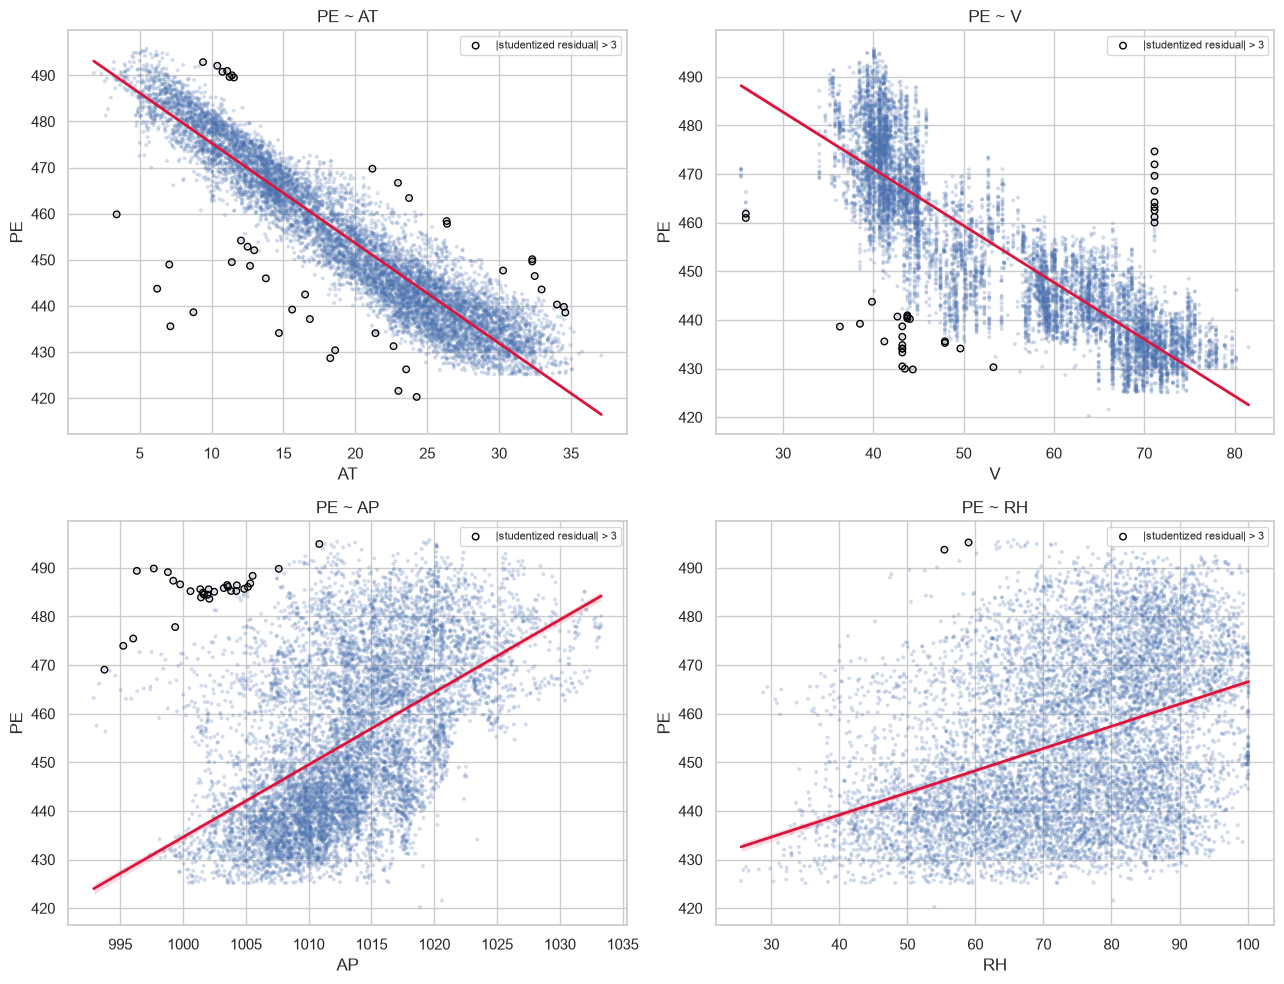

,Coefficient,Std. Error,p-value,R-squared,Potential outliers (|studentized residual| > 3)
Predictor,,,,,
AT,-2.171320,0.007443,0.0,0.898948,42
V,-1.168135,0.006776,0.0,0.756518,33
AP,1.489872,0.025126,0.0,0.268769,30
RH,0.455650,0.011006,0.0,0.151939,2


In [6]:
predictors = ["AT", "V", "AP", "RH"]
response = "PE"
simple_models = {}
simple_rows = []

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for predictor, ax in zip(predictors, axes.ravel()):
    X_simple = sm.add_constant(df[[predictor]])
    model = sm.OLS(df[response], X_simple).fit()
    simple_models[predictor] = model

    influence = model.get_influence()
    studentized = influence.resid_studentized_external
    outlier_mask = np.abs(studentized) > 3

    simple_rows.append({
        "Predictor": predictor,
        "Coefficient": model.params[predictor],
        "Std. Error": model.bse[predictor],
        "p-value": model.pvalues[predictor],
        "R-squared": model.rsquared,
        "Potential outliers (|studentized residual| > 3)": int(outlier_mask.sum()),
    })

    sns.regplot(
        data=df, x=predictor, y=response, ax=ax,
        scatter_kws={"s": 8, "alpha": 0.25, "edgecolor": "none"},
        line_kws={"color": "crimson", "linewidth": 2},
    )
    if outlier_mask.any():
        ax.scatter(
            df.loc[outlier_mask, predictor], df.loc[outlier_mask, response],
            s=22, facecolors="none", edgecolors="black", label="|studentized residual| > 3"
        )
        ax.legend(fontsize=8)
    ax.set_title(f"PE ~ {predictor}")

plt.tight_layout()
plt.show()

simple_results = pd.DataFrame(simple_rows).set_index("Predictor")
display(simple_results)


All four univariate slopes have very small p-values, so each predictor is statistically associated with PE when considered alone. AT and V explain substantially more variation than AP or RH. The studentized-residual diagnostic identifies observations worth investigating, but observations should not be removed merely because they are unusual. Without evidence of recording error, the full data set is retained.


### (d) Multiple Regression


In [7]:
X_all = sm.add_constant(df[predictors])
multiple_model = sm.OLS(df[response], X_all).fit()
print(multiple_model.summary())

multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Std. Error": multiple_model.bse,
    "p-value": multiple_model.pvalues,
})
display(multiple_results)


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:14:08   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

,Coefficient,Std. Error,p-value
const,454.609274,9.748512,0.000000e+00
AT,-1.977513,0.015289,0.000000e+00
V,-0.233916,0.007282,4.375305e-215
AP,0.062083,0.009458,5.507109e-11
RH,-0.158054,0.004168,3.104584e-293


At alpha = 0.05, the null hypothesis H0: beta_j = 0 is rejected for all four predictors (AT, V, AP, and RH). Their p-values are all below 0.05. The signs and magnitudes differ from some simple-regression estimates because the multiple model holds the other predictors fixed and accounts for correlation among predictors.


### (e) Compare 1(c) with 1(d)


,Simple regression coefficient,Multiple regression coefficient
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


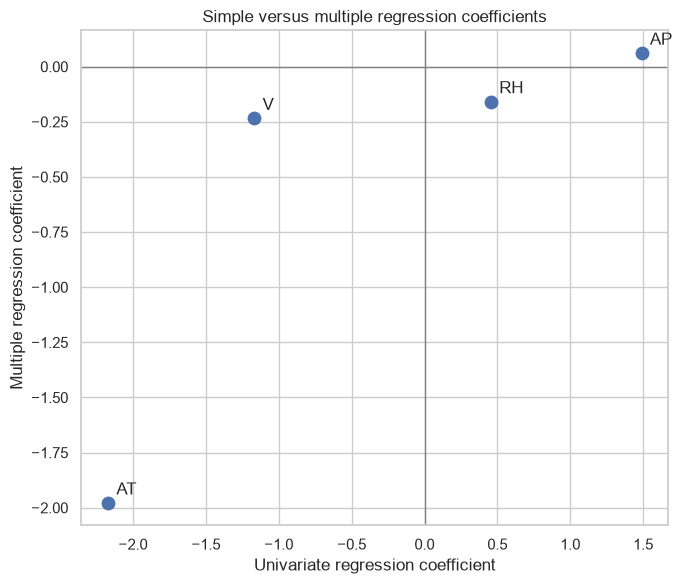

In [8]:
coef_comparison = pd.DataFrame({
    "Simple regression coefficient": [simple_models[p].params[p] for p in predictors],
    "Multiple regression coefficient": [multiple_model.params[p] for p in predictors],
}, index=predictors)
display(coef_comparison)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    coef_comparison["Simple regression coefficient"],
    coef_comparison["Multiple regression coefficient"],
    s=80,
)
for predictor, row in coef_comparison.iterrows():
    ax.annotate(
        predictor,
        (row["Simple regression coefficient"], row["Multiple regression coefficient"]),
        xytext=(6, 6), textcoords="offset points"
    )
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Univariate regression coefficient")
ax.set_ylabel("Multiple regression coefficient")
ax.set_title("Simple versus multiple regression coefficients")
plt.tight_layout()
plt.show()


The coefficients are not expected to lie on a 45-degree line. Each simple regression mixes a predictor's direct association with associations carried through correlated predictors. Multiple regression estimates the partial effect after holding the other variables fixed; this explains changes in magnitude and, where present, sign.


### (f) Nonlinear Association


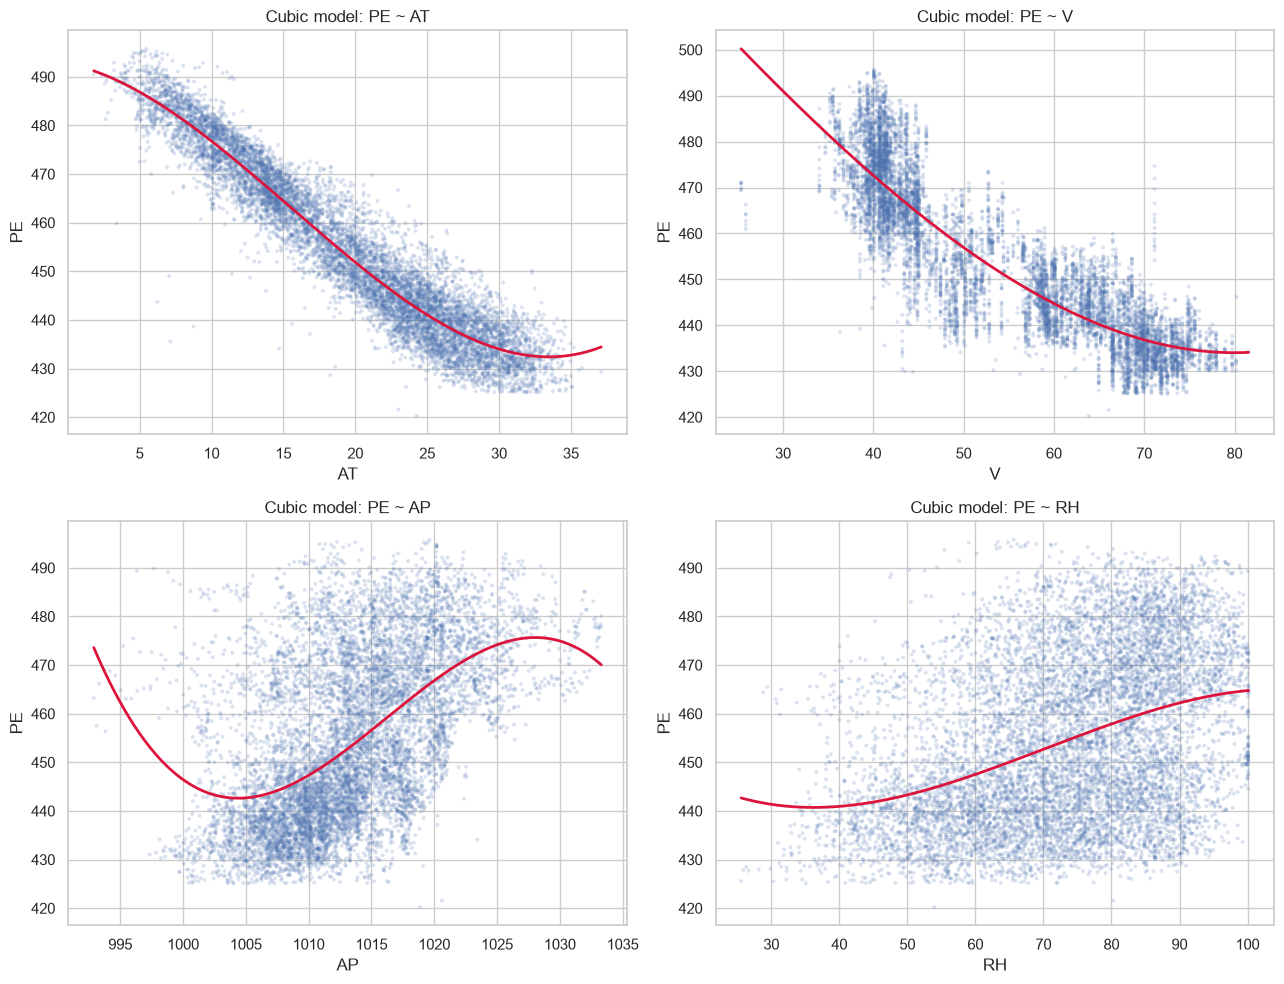

,p-value linear,p-value quadratic,p-value cubic,Joint p-value (quadratic and cubic),R-squared,Evidence of nonlinearity at 0.05
Predictor,,,,,,
AT,0.000000e+00,3.311808e-231,3.652185e-110,3.478379e-285,0.911883,True
V,0.000000e+00,8.977010e-131,1.373489e-02,7.040304e-165,0.775022,True
AP,0.000000e+00,2.192722e-46,2.123338e-67,4.209145e-84,0.297543,True
RH,9.648727e-152,1.013949e-01,1.440279e-05,3.799622e-05,0.153743,True


In [9]:
nonlinear_rows = []
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for predictor, ax in zip(predictors, axes.ravel()):
    x = df[predictor].to_numpy()
    x_mean = x.mean()
    x_std = x.std(ddof=0)
    z = (x - x_mean) / x_std
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(z.reshape(-1, 1))
    names = [f"{predictor}_z", f"{predictor}_z^2", f"{predictor}_z^3"]
    X_poly_df = pd.DataFrame(X_poly, columns=names, index=df.index)
    model = sm.OLS(df[response], sm.add_constant(X_poly_df)).fit()

    # Jointly test whether the quadratic and cubic coefficients are zero.
    # This gives a direct, numerically stable test of nonlinearity.
    restriction = np.zeros((2, 4))
    restriction[0, 2] = 1
    restriction[1, 3] = 1
    nonlinear_test = model.f_test(restriction)
    nonlinear_pvalue = float(nonlinear_test.pvalue)

    nonlinear_rows.append({
        "Predictor": predictor,
        "p-value linear": model.pvalues[f"{predictor}_z"],
        "p-value quadratic": model.pvalues[f"{predictor}_z^2"],
        "p-value cubic": model.pvalues[f"{predictor}_z^3"],
        "Joint p-value (quadratic and cubic)": nonlinear_pvalue,
        "R-squared": model.rsquared,
        "Evidence of nonlinearity at 0.05": nonlinear_pvalue < 0.05,
    })

    x_grid = np.linspace(x.min(), x.max(), 300)
    z_grid = (x_grid - x_mean) / x_std
    grid_poly = poly.transform(z_grid.reshape(-1, 1))
    grid_df = pd.DataFrame(grid_poly, columns=names)
    y_grid = model.predict(sm.add_constant(grid_df, has_constant="add"))
    ax.scatter(x, df[response], s=8, alpha=0.2, edgecolor="none")
    ax.plot(x_grid, y_grid, color="crimson", linewidth=2)
    ax.set_xlabel(predictor)
    ax.set_ylabel(response)
    ax.set_title(f"Cubic model: PE ~ {predictor}")

plt.tight_layout()
plt.show()
nonlinear_results = pd.DataFrame(nonlinear_rows).set_index("Predictor")
display(nonlinear_results)


Each predictor is centered and standardized before constructing its powers. This improves numerical conditioning without reducing model flexibility. Evidence of nonlinear association is assessed by the joint F-test of H0: beta_2 = beta_3 = 0; a joint p-value below 0.05 rejects a purely linear relationship. Because the sample is large, statistical significance should also be interpreted together with the fitted curves and R-squared.


### (g) Interactions of Predictors


In [10]:
interaction_poly = PolynomialFeatures(
    degree=2, interaction_only=True, include_bias=False
)
X_interaction_array = interaction_poly.fit_transform(df[predictors])
interaction_names = interaction_poly.get_feature_names_out(predictors)
X_interaction = pd.DataFrame(
    X_interaction_array, columns=interaction_names, index=df.index
)
interaction_model = sm.OLS(
    df[response], sm.add_constant(X_interaction)
).fit()

pairwise_names = [name for name in interaction_names if " " in name]
interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[pairwise_names],
    "p-value": interaction_model.pvalues[pairwise_names],
    "Significant at 0.05": interaction_model.pvalues[pairwise_names] < 0.05,
}).sort_values("p-value")
display(interaction_results)


,Coefficient,p-value,Significant at 0.05
AT V,0.020971,3.333358e-117,True
AT RH,-0.005230,1.216944e-10,True
V AP,0.006812,2.877026e-07,True
AP RH,-0.001612,3.360557e-02,True
V RH,0.000839,8.619366e-02,False
AT AP,0.001759,4.520509e-01,False


The model tests all six pairwise interactions while retaining all four main effects. At alpha = 0.05, AT:V, AT:RH, V:AP, and AP:RH are significant. AT:AP and V:RH are not significant. Significant terms provide evidence that the effect of one predictor changes with the level of another predictor.


### (h) Model Improvement


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df[predictors], df[response], test_size=0.30, random_state=RANDOM_STATE
)

# Baseline linear regression with all four predictors.
baseline_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
baseline_train_pred = baseline_model.predict(sm.add_constant(X_train))
baseline_test_pred = baseline_model.predict(sm.add_constant(X_test))

# Expanded model: all main effects, squares, and pairwise interactions.
degree2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_degree2_array = degree2.fit_transform(X_train)
X_test_degree2_array = degree2.transform(X_test)
degree2_names = degree2.get_feature_names_out(predictors)
X_train_degree2 = pd.DataFrame(
    X_train_degree2_array, columns=degree2_names, index=X_train.index
)
X_test_degree2 = pd.DataFrame(
    X_test_degree2_array, columns=degree2_names, index=X_test.index
)

# Backward elimination for derived terms. Main effects are always retained to
# enforce the hierarchy principle whenever a square or interaction is present.
selected_terms = list(degree2_names)
elimination_log = []
while True:
    current_model = sm.OLS(
        y_train, sm.add_constant(X_train_degree2[selected_terms])
    ).fit()
    removable = [term for term in selected_terms if term not in predictors]
    if not removable:
        break
    removable_pvalues = current_model.pvalues[removable]
    worst_term = removable_pvalues.idxmax()
    worst_pvalue = removable_pvalues.loc[worst_term]
    if worst_pvalue <= 0.05:
        break
    selected_terms.remove(worst_term)
    elimination_log.append((worst_term, worst_pvalue))

reduced_model = sm.OLS(
    y_train, sm.add_constant(X_train_degree2[selected_terms])
).fit()
reduced_train_pred = reduced_model.predict(
    sm.add_constant(X_train_degree2[selected_terms], has_constant="add")
)
reduced_test_pred = reduced_model.predict(
    sm.add_constant(X_test_degree2[selected_terms], has_constant="add")
)

linear_mse_results = pd.DataFrame({
    "Train MSE": [
        mean_squared_error(y_train, baseline_train_pred),
        mean_squared_error(y_train, reduced_train_pred),
    ],
    "Test MSE": [
        mean_squared_error(y_test, baseline_test_pred),
        mean_squared_error(y_test, reduced_test_pred),
    ],
}, index=["All-predictor linear model", "Reduced quadratic + interaction model"])

print("Removed derived terms and their p-values at removal:")
display(pd.DataFrame(elimination_log, columns=["Removed term", "p-value"]))
print("Terms retained in the reduced hierarchical model:")
print(selected_terms)
display(linear_mse_results)


Removed derived terms and their p-values at removal:


,Removed term,p-value
0,V RH,0.867382
1,V^2,0.607733
2,V AP,0.357826


Terms retained in the reduced hierarchical model:
['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT AP', 'AT RH', 'AP^2', 'AP RH', 'RH^2']


,Train MSE,Test MSE
All-predictor linear model,20.580840,21.239857
Reduced quadratic + interaction model,17.890843,18.660040


Both models use exactly the same 70/30 split. Selection is performed using only the training data. Main effects are retained whenever higher-order terms are considered, satisfying the hierarchy principle. The preferred linear-family model is the one with the smaller test MSE, not necessarily the smaller training MSE.


### (i) KNN Regression


,Best k,Train MSE at best k,Test MSE at best k
Raw features,5,10.600769,15.726820
Normalized features,4,8.591433,14.305669


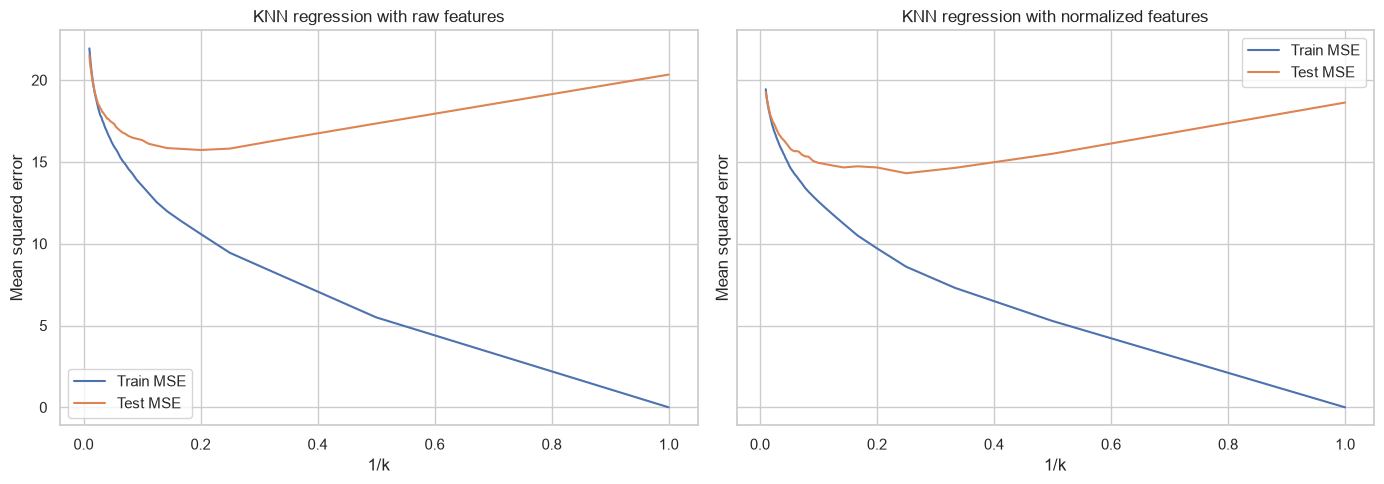

In [12]:
k_values = np.arange(1, 101)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_rows = []
for k in k_values:
    raw_model = KNeighborsRegressor(n_neighbors=k)
    raw_model.fit(X_train, y_train)
    raw_train_mse = mean_squared_error(y_train, raw_model.predict(X_train))
    raw_test_mse = mean_squared_error(y_test, raw_model.predict(X_test))

    normalized_model = KNeighborsRegressor(n_neighbors=k)
    normalized_model.fit(X_train_scaled, y_train)
    normalized_train_mse = mean_squared_error(
        y_train, normalized_model.predict(X_train_scaled)
    )
    normalized_test_mse = mean_squared_error(
        y_test, normalized_model.predict(X_test_scaled)
    )

    knn_rows.append({
        "k": k,
        "1/k": 1 / k,
        "Raw train MSE": raw_train_mse,
        "Raw test MSE": raw_test_mse,
        "Normalized train MSE": normalized_train_mse,
        "Normalized test MSE": normalized_test_mse,
    })

knn_results = pd.DataFrame(knn_rows)
best_raw = knn_results.loc[knn_results["Raw test MSE"].idxmin()]
best_normalized = knn_results.loc[
    knn_results["Normalized test MSE"].idxmin()
]

display(pd.DataFrame({
    "Best k": [int(best_raw["k"]), int(best_normalized["k"])],
    "Train MSE at best k": [
        best_raw["Raw train MSE"], best_normalized["Normalized train MSE"]
    ],
    "Test MSE at best k": [
        best_raw["Raw test MSE"], best_normalized["Normalized test MSE"]
    ],
}, index=["Raw features", "Normalized features"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].plot(knn_results["1/k"], knn_results["Raw train MSE"], label="Train MSE")
axes[0].plot(knn_results["1/k"], knn_results["Raw test MSE"], label="Test MSE")
axes[0].set_title("KNN regression with raw features")
axes[1].plot(
    knn_results["1/k"], knn_results["Normalized train MSE"], label="Train MSE"
)
axes[1].plot(
    knn_results["1/k"], knn_results["Normalized test MSE"], label="Test MSE"
)
axes[1].set_title("KNN regression with normalized features")
for ax in axes:
    ax.set_xlabel("1/k")
    ax.set_ylabel("Mean squared error")
    ax.legend()
plt.tight_layout()
plt.show()


The scaler is fitted on the training set only and then applied to the test set. This prevents test-set information from leaking into model training. Normalization is important for KNN because its neighbor search is distance-based and the predictors have different numerical scales.


### (j) Compare KNN and Linear Regression


In [13]:
comparison = pd.DataFrame({
    "Train MSE": [
        linear_mse_results.loc["All-predictor linear model", "Train MSE"],
        linear_mse_results.loc["Reduced quadratic + interaction model", "Train MSE"],
        best_raw["Raw train MSE"],
        best_normalized["Normalized train MSE"],
    ],
    "Test MSE": [
        linear_mse_results.loc["All-predictor linear model", "Test MSE"],
        linear_mse_results.loc["Reduced quadratic + interaction model", "Test MSE"],
        best_raw["Raw test MSE"],
        best_normalized["Normalized test MSE"],
    ],
}, index=[
    "All-predictor linear model",
    "Reduced quadratic + interaction model",
    f"Raw-feature KNN (k={int(best_raw['k'])})",
    f"Normalized-feature KNN (k={int(best_normalized['k'])})",
])

display(comparison.sort_values("Test MSE"))
best_model_name = comparison["Test MSE"].idxmin()
print(f"The smallest test MSE is achieved by: {best_model_name}")


,Train MSE,Test MSE
Normalized-feature KNN (k=4),8.591433,14.305669
Raw-feature KNN (k=5),10.600769,15.726820
Reduced quadratic + interaction model,17.890843,18.660040
All-predictor linear model,20.580840,21.239857


The smallest test MSE is achieved by: Normalized-feature KNN (k=4)


The final comparison is based on held-out test MSE. Training error alone is not used for model selection because a more flexible method can fit the training data very closely while generalizing poorly. The table identifies the best-performing method for this fixed split.


## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method is likely to perform better. The large sample gives enough information to estimate a flexible relationship with relatively low variance, while the small number of predictors limits dimensionality.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

An inflexible method is likely to perform better. A highly flexible method would have high variance and could severely overfit when there are many predictors but few observations.

### (c) The relationship between the predictors and response is highly nonlinear.

A flexible method is likely to perform better because an inflexible method would have excessive bias and could not represent the nonlinear relationship adequately.

### (d) The variance of the error terms is extremely high.

An inflexible method is likely to perform better. High irreducible noise makes a flexible method prone to fitting noise, increasing variance without improving the underlying signal estimate.


## 3. ISLR: 2.4.7

The six training observations from the exercise are entered below, and their Euclidean distances to the test point (0, 0, 0) are calculated directly.


In [14]:
exercise_247 = pd.DataFrame({
    "Observation": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
})
exercise_247["Distance to (0,0,0)"] = np.sqrt(
    exercise_247[["X1", "X2", "X3"]].pow(2).sum(axis=1)
)
display(exercise_247)
display(exercise_247.sort_values("Distance to (0,0,0)"))


,Observation,X1,X2,X3,Y,"Distance to (0,0,0)"
0,1,0,3,0,Red,3.000000
1,2,2,0,0,Red,2.000000
2,3,0,1,3,Red,3.162278
3,4,0,1,2,Green,2.236068
4,5,-1,0,1,Green,1.414214
5,6,1,1,1,Red,1.732051


,Observation,X1,X2,X3,Y,"Distance to (0,0,0)"
4,5,-1,0,1,Green,1.414214
5,6,1,1,1,Red,1.732051
1,2,2,0,0,Red,2.000000
3,4,0,1,2,Green,2.236068
0,1,0,3,0,Red,3.000000
2,3,0,1,3,Red,3.162278


### (a) Euclidean distances

The distances for observations 1 through 6 are 3, 2, sqrt(10), sqrt(5), sqrt(2), and sqrt(3), respectively.

### (b) Prediction with K = 1

The nearest observation is observation 5, whose class is Green. Therefore the K = 1 prediction is **Green**.

### (c) Prediction with K = 3

The three nearest observations are 5 (Green), 6 (Red), and 2 (Red). Red has the majority, so the K = 3 prediction is **Red**.

### (d) Highly nonlinear Bayes decision boundary

We would expect the best K to be relatively **small**. A small K produces a more flexible decision boundary capable of following strong nonlinearities. A large K averages over a broad neighborhood and produces a smoother, less flexible boundary.
